In [ ]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
sv_file = pd.read_hdf('data/analysis_public_os_data_merged_consensus_svs_v2.h5')
sv_file.to_csv('data/sv_file_v2.csv', index=False)
sv_file['name'].value_counts().to_csv('data/sv_file_v2_name_counts.csv')

In [3]:
# Find duplicates by (name, chr1, pos1, chr2, pos2)
dup_cols = ['name', 'chr1', 'pos1', 'chr2', 'pos2']
dup_mask = sv_file.duplicated(subset=dup_cols, keep=False)  # keep=False marks all dupes
duplicates = sv_file[dup_mask].sort_values(dup_cols)

n_dup_rows = dup_mask.sum()
n_unique_dup_groups = duplicates.groupby(dup_cols).ngroups

print(f"Rows that are part of a duplicate group: {n_dup_rows}")
print(f"Unique (name, chr1, pos1, chr2, pos2) that have duplicates: {n_unique_dup_groups}")
duplicates

Rows that are part of a duplicate group: 18
Unique (name, chr1, pos1, chr2, pos2) that have duplicates: 9


,num,chr1,str1,pos1,chr2,str2,pos2,class,span,somatic,somatic_score,SvABA,Manta,VCF_TALT,VCF_NALT,VCF_TREF,VCF_NREF,name
65616,129,8,1,71337120,8,0,96527662,long_range,25190541.0,1,76.0,1,0,117,0,274,172,SJOS001109_D1-SJOS001109_G1
65617,946,8,0,71337120,8,0,96527662,long_range,25190751.0,1,33.0,0,1,178,0,274,172,SJOS001109_D1-SJOS001109_G1
67868,621,8,1,53550082,10,0,108324217,inter_chr,NaN,1,6.0,1,1,21,0,92,125,SJOS001115_D1-SJOS001115_G1
67869,275,8,0,53550082,10,0,108324217,inter_chr,NaN,1,20.0,0,1,20,0,92,125,SJOS001115_D1-SJOS001115_G1
68520,629,8,1,53550082,10,0,108324217,inter_chr,NaN,1,6.0,1,1,21,0,92,100,SJOS001115_D1-SJOS014_G
68521,276,8,0,53550082,10,0,108324217,inter_chr,NaN,1,20.0,0,1,20,0,92,100,SJOS001115_D1-SJOS014_G
71493,7,1,1,91184132,1,1,97881403,long_range,6697271.0,1,30.0,1,1,41,0,159,138,SJOS001127_D1-SJOS001127_G1
71494,5,1,0,91184132,1,0,97881403,long_range,6697271.0,1,33.0,1,1,37,0,159,138,SJOS001127_D1-SJOS001127_G1
78561,770,3,0,54135805,6,1,136777219,inter_chr,NaN,1,6.518921,1,1,13,0,125,64,SJOS013_D-SJOS013_G
78562,8668,3,1,54135805,6,0,136777219,inter_chr,NaN,1,10.0,1,1,18,0,125,64,SJOS013_D-SJOS013_G


In [ ]:
sv_file_dup_cleaned = sv_file.copy()
# chose the variant to remove based on VAFs
to_remove = [
    ('SJOS001109_D1-SJOS001109_G1', '8', '0', 71337120, '8', '0', 96527662),
    ('SJOS001115_D1-SJOS001115_G1', '8', '0', 53550082, '10', '0', 108324217),
    ('SJOS001115_D1-SJOS014_G', '8', '0', 53550082, '10', '0', 108324217),
    ('SJOS001127_D1-SJOS001127_G1', '1', '0', 91184132, '1', '0', 97881403),
    ('SJOS013_D-SJOS013_G', '3', '0', 54135805, '6', '1', 136777219),
    ('SJOS013_D-SJOS013_H', '3', '0', 54135805, '6', '1', 136777219),
    ('SJOS071781_D1-SJOS071781_G1', '9', '1', 15559659, '9', '0', 15901707),
    ('TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A', '9', '0', 69961783, '9', '0', 70121835),
    ('TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A', '19', '1', 27806585, '19', '0', 28688804),
]
keys = ['name', 'chr1', 'str1', 'pos1', 'chr2', 'str2', 'pos2']

to_remove_df = pd.DataFrame(to_remove, columns=keys)

def make_key(df):
    return df[keys].astype(str).agg('_'.join, axis=1)

sv_file_dup_cleaned['_key'] = make_key(sv_file_dup_cleaned)
to_remove_keys = set(make_key(to_remove_df))

sv_file_dup_cleaned = sv_file_dup_cleaned[~sv_file_dup_cleaned['_key'].isin(to_remove_keys)].drop(columns=['_key'])
print(len(sv_file_dup_cleaned))
print(len(sv_file))
sv_file_dup_cleaned.to_csv('data/sv_file_v2.csv', index=False)
sv_file_dup_cleaned.to_hdf('data/sv_file_dup_cleaned.h5', key='df', mode='w')

108258
108267


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_25868/1981075861.py:28: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['num', 'chr1', 'str1', 'pos1', 'chr2', 'str2', 'pos2', 'class', 'span',
       'somatic', 'somatic_score', 'SvABA', 'Manta', 'VCF_TALT', 'VCF_NALT',
       'VCF_TREF', 'VCF_NREF', 'name'],
      dtype='object')]

  sv_file_dup_cleaned.to_hdf('sv_file_dup_cleaned.h5', key='df', mode='w')


'sv_file' is the consensus SVs, 'sv2_file' is the preconsensus SVs, 'pairs' are the tumor-normal pairs across cohorts, 'pair_counts' are the number of SVs per pair in the cohort  
1. Understanding filtering of SVs from preconsensus to consensus
2. What pairs are represented in the SV file vs the cohort info?
3. How many SVs are there per pair?


In [5]:
mutation_counts = pd.crosstab(sv_file['name'], sv_file['class'], margins=True).reset_index()
min_mutations = mutation_counts['All'][:-1].min()
max_mutations = mutation_counts['All'][:-1].max()

print(f"Range of mutations per sample:")
print(f"Minimum: {min_mutations}")
print(f"Maximum: {max_mutations}")

Range of mutations per sample:
Minimum: 1
Maximum: 35487


In [ ]:
sv2_file = pd.read_hdf('data/analysis_public_os_data_merged_preconsensus_svs_v2.h5')
sv2_file

,num,chr1,str1,pos1,chr2,str2,pos2,class,span,somatic,somatic_score,SvABA,Manta,VCF_TALT,VCF_NALT,VCF_TREF,VCF_NREF,name
0,1557,4,0,49107494,4,1,49118998,deletion,11504,1,19.0,1,0,24,43,727,2003,09T01-09N01
1,1554,4,1,49108437,4,0,49119382,tandem_dup,10857,1,41.0,1,0,54,111,738,1835,09T01-09N01
2,1555,4,1,49120851,4,1,49648103,inversion,527080,1,29.0,1,0,10,15,215,521,09T01-09N01
3,908,1,1,185703,1,1,186701,inversion,999.0,1,5.0,0,1,12,0,228,144,09T02-09N01
4,614,1,0,3680543,1,1,3731731,deletion,51189.0,1,15.0,0,1,11,0,149,86,09T02-09N01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179985,39,23,1,7290822,23,0,19851515,long_range,12560692.0,1,7.0,1,1,5,0,138,48,WGS_15_2-WGS_16_2
179986,139,23,1,16383908,23,1,21644961,long_range,5261053.0,1,4.0,0,1,5,0,125,65,WGS_15_2-WGS_16_2
179987,57,23,1,22458058,23,1,22464220,inversion,6162.0,1,4.0,1,0,3,0,120,58,WGS_15_2-WGS_16_2
179988,84,23,0,77424480,23,1,77597375,deletion,172897.0,1,8.0,0,1,8,0,64,45,WGS_15_2-WGS_16_2


In [7]:
# 1. Understanding filtering of SVs from preconsensus to consensus
both_callers_df = sv_file[(sv_file['Manta'] == 1) & (sv_file['SvABA'] == 1)]
both_callers_pre_df = sv2_file[(sv2_file['Manta'] == 1) & (sv2_file['SvABA'] == 1)]

print(f"Total SVs in consensus data: {len(sv_file)}")
print(f"SVs called by both Manta and SvABA in consensus data: {len(both_callers_df)} ({(len(both_callers_df) / len(sv_file) * 100):.2f}%))")
print(f"Total SVs in preconsensus data: {len(sv2_file)}")
print(f"SVs called by both Manta and SvABA in preconsensus data: {len(both_callers_pre_df)} ({(len(both_callers_pre_df) / len(sv2_file) * 100):.2f}%)")
print(f"Number of SVs called by both filtered out: {len(both_callers_pre_df) - len(both_callers_df)}")
print(f"Percentage filtered out: {((len(both_callers_pre_df) - len(both_callers_df)) / len(both_callers_pre_df) * 100):.2f}%")

Total SVs in consensus data: 108267
SVs called by both Manta and SvABA in consensus data: 52920 (48.88%))
Total SVs in preconsensus data: 179990
SVs called by both Manta and SvABA in preconsensus data: 72337 (40.19%)
Number of SVs called by both filtered out: 19417
Percentage filtered out: 26.84%


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_71894/3912569651.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pre_count = caller_comparison_pre['Counts'][i]
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_71894/3912569651.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  post_count = caller_comparison['Counts'][i]


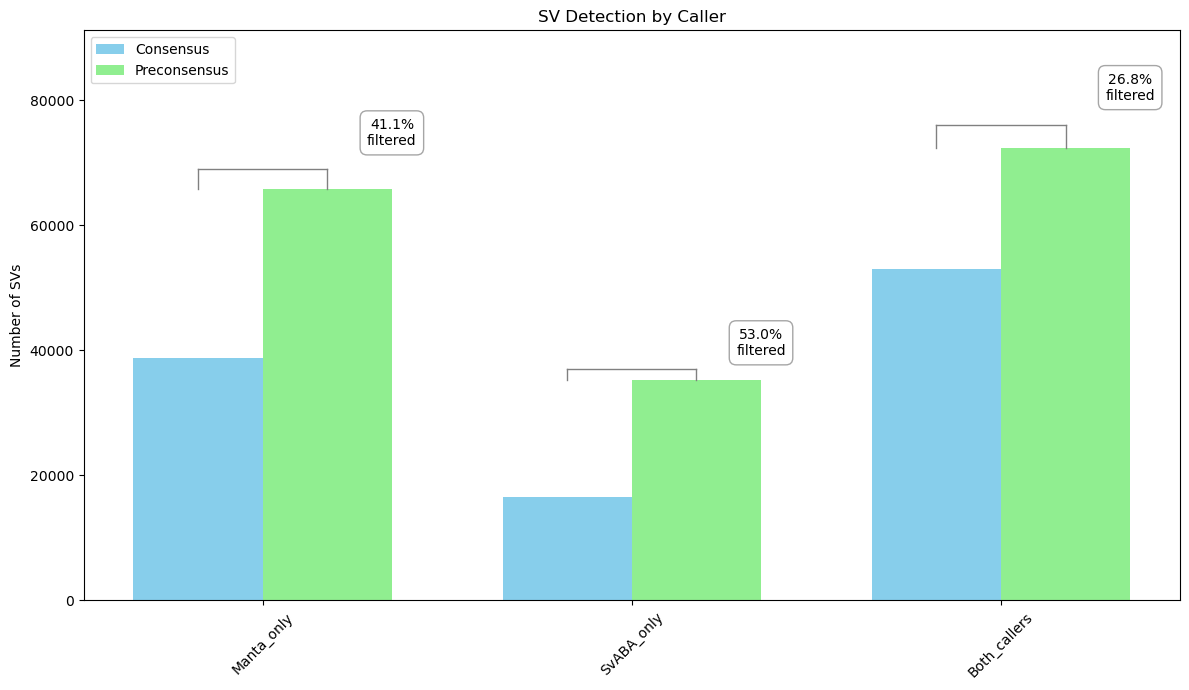

In [8]:
caller_comparison = pd.DataFrame({
    'Counts': [
        len(sv_file[sv_file['Manta'] == 1]) - len(both_callers_df), 
        len(sv_file[sv_file['SvABA'] == 1]) - len(both_callers_df), 
        len(both_callers_df) 
    ]
}, index=['Manta_only', 'SvABA_only', 'Both_callers'])

caller_comparison_pre = pd.DataFrame({
    'Counts': [
        len(sv2_file[sv2_file['Manta'] == 1]) - len(both_callers_pre_df), 
        len(sv2_file[sv2_file['SvABA'] == 1]) - len(both_callers_pre_df), 
        len(both_callers_pre_df) 
    ]
}, index=['Manta_only', 'SvABA_only', 'Both_callers'])

plt.figure(figsize=(12, 7))

x = np.arange(len(caller_comparison.index))
width = 0.35

plt.bar(x - width/2, caller_comparison['Counts'], width, label='Consensus', color='skyblue')
plt.bar(x + width/2, caller_comparison_pre['Counts'], width, label='Preconsensus', color='lightgreen')

# percentage filtered out annotations
for i in x:
    pre_count = caller_comparison_pre['Counts'][i]
    post_count = caller_comparison['Counts'][i]
    percent_filtered = ((pre_count - post_count) / pre_count * 100) if pre_count > 0 else 0
    
    max_height = max(pre_count, post_count)
    
    plt.annotate(
        f'{percent_filtered:.1f}%\nfiltered',
        xy=(i + width/2, max_height),
        xytext=(i + width, max_height * 1.1),
        ha='center',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.7)
    )
    
    plt.plot([i - width/2, i + width/2], [max_height * 1.05, max_height * 1.05], 
             color='gray', linestyle='-', linewidth=1)
    plt.plot([i - width/2, i - width/2], [max_height, max_height * 1.05], 
             color='gray', linestyle='-', linewidth=1)
    plt.plot([i + width/2, i + width/2], [max_height, max_height * 1.05], 
             color='gray', linestyle='-', linewidth=1)

plt.title('SV Detection by Caller')
plt.ylabel('Number of SVs')
plt.xticks(x, caller_comparison.index, rotation=45)
plt.legend()

plt.margins(y=0.2)

plt.tight_layout()

In [ ]:
# filter to included samples
included_samples = pd.read_csv('data/final_samples.csv')
analysis_included_samples = pd.read_csv("data/final_analysis_samples.csv")

print("Number of samples:", len(included_samples))
print("Number of unique participant samples:", len(analysis_included_samples))

Number of samples: 236
Number of unique participant samples: 207


In [10]:
# 2. What pairs are represented in the SV file vs the cohort info?
name_counts = sv_file['name'].value_counts()

# get unique values from both columns for comparison
unique_subset = set(sv_file['name'].dropna().unique()) # samples w/ SVs (after filtering)
unique_sv = set(included_samples['tumor_normal_pair'].dropna().unique()) # samples in cohort 

# pairs only in SV file 
only_in_subset = unique_subset - unique_sv

# pairs not in SV file (only in cohort info)
only_in_sv = unique_sv - unique_subset

# values in both (intersection)
in_both = unique_subset & unique_sv

# comparison summary
print(f"Total unique samples in included samples SV file: {len(unique_subset)}")
print(f"Total unique samples in cohort info: {len(unique_sv)}")
print(f"Values only in included samples SV file: {len(only_in_subset)}")
print(f"Values only in cohort info (w/o SVs): {len(only_in_sv)}")
print(f"Values in both: {len(in_both)}")

# the actual different values
print("\nValues only in cohort info:")
print(only_in_sv)

Total unique samples in included samples SV file: 292
Total unique samples in cohort info: 236
Values only in included samples SV file: 58
Values only in cohort info (w/o SVs): 2
Values in both: 234

Values only in cohort info:
{'SJOS033930_D1-SJOS033930_G1', 'TARGET-40-PALECC-01A-TARGET-40-PALECC-10A'}


In [ ]:
# 3. How many SVs are there per pair?

pair_counts = pd.DataFrame({
    'tumor_normal_pair': analysis_included_samples['tumor_normal_pair'],
    'sv_count': analysis_included_samples['tumor_normal_pair'].map(name_counts).fillna(0)
})
pair_counts = pair_counts.sort_values('sv_count', ascending=False)

# summary
print("\nSummary:")
print(f"Total pairs: {len(pair_counts)}")
print(f"Pairs without SVs: {len(pair_counts[pair_counts['sv_count'] == 0])}")
print("\nPairs with no SVs:")
print(pair_counts[pair_counts['sv_count'] == 0])
pair_counts.to_csv('data/sv_burden.csv', index=False)


Summary:
Total pairs: 207
Pairs without SVs: 2

Pairs with no SVs:
                             tumor_normal_pair  sv_count
177  TARGET-40-PALECC-01A-TARGET-40-PALECC-10A       0.0
153                SJOS033930_D1-SJOS033930_G1       0.0


Min: 0
25th percentile: 90
50th percentile: 215
75th percentile: 328
Max: 2861


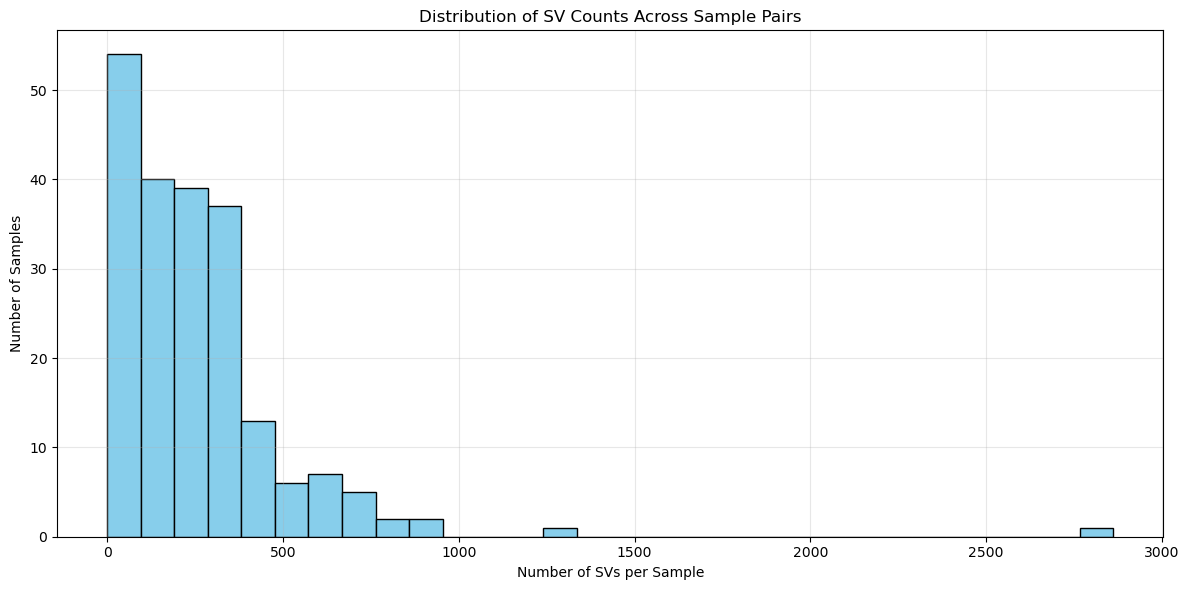

In [14]:
plt.figure(figsize=(12, 6))

# histogram
plt.hist(pair_counts['sv_count'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of SV Counts Across Sample Pairs')
plt.xlabel('Number of SVs per Sample')
plt.ylabel('Number of Samples')

plt.grid(True, alpha=0.3)

stats = {
    'Min': pair_counts['sv_count'].min(),
    '25th percentile': pair_counts['sv_count'].quantile(0.25),
    '50th percentile': pair_counts['sv_count'].quantile(0.5),
    '75th percentile': pair_counts['sv_count'].quantile(0.75),
    'Max': pair_counts['sv_count'].max()
}

for stat, value in stats.items():
    print(f"{stat}: {value:.0f}")

plt.tight_layout()

Filtered data statistics (excluding 2861 SV outlier):
Count: 207
Min: 0
25th percentile: 90
50th percentile (Median): 215
75th percentile: 328
Max: 2861


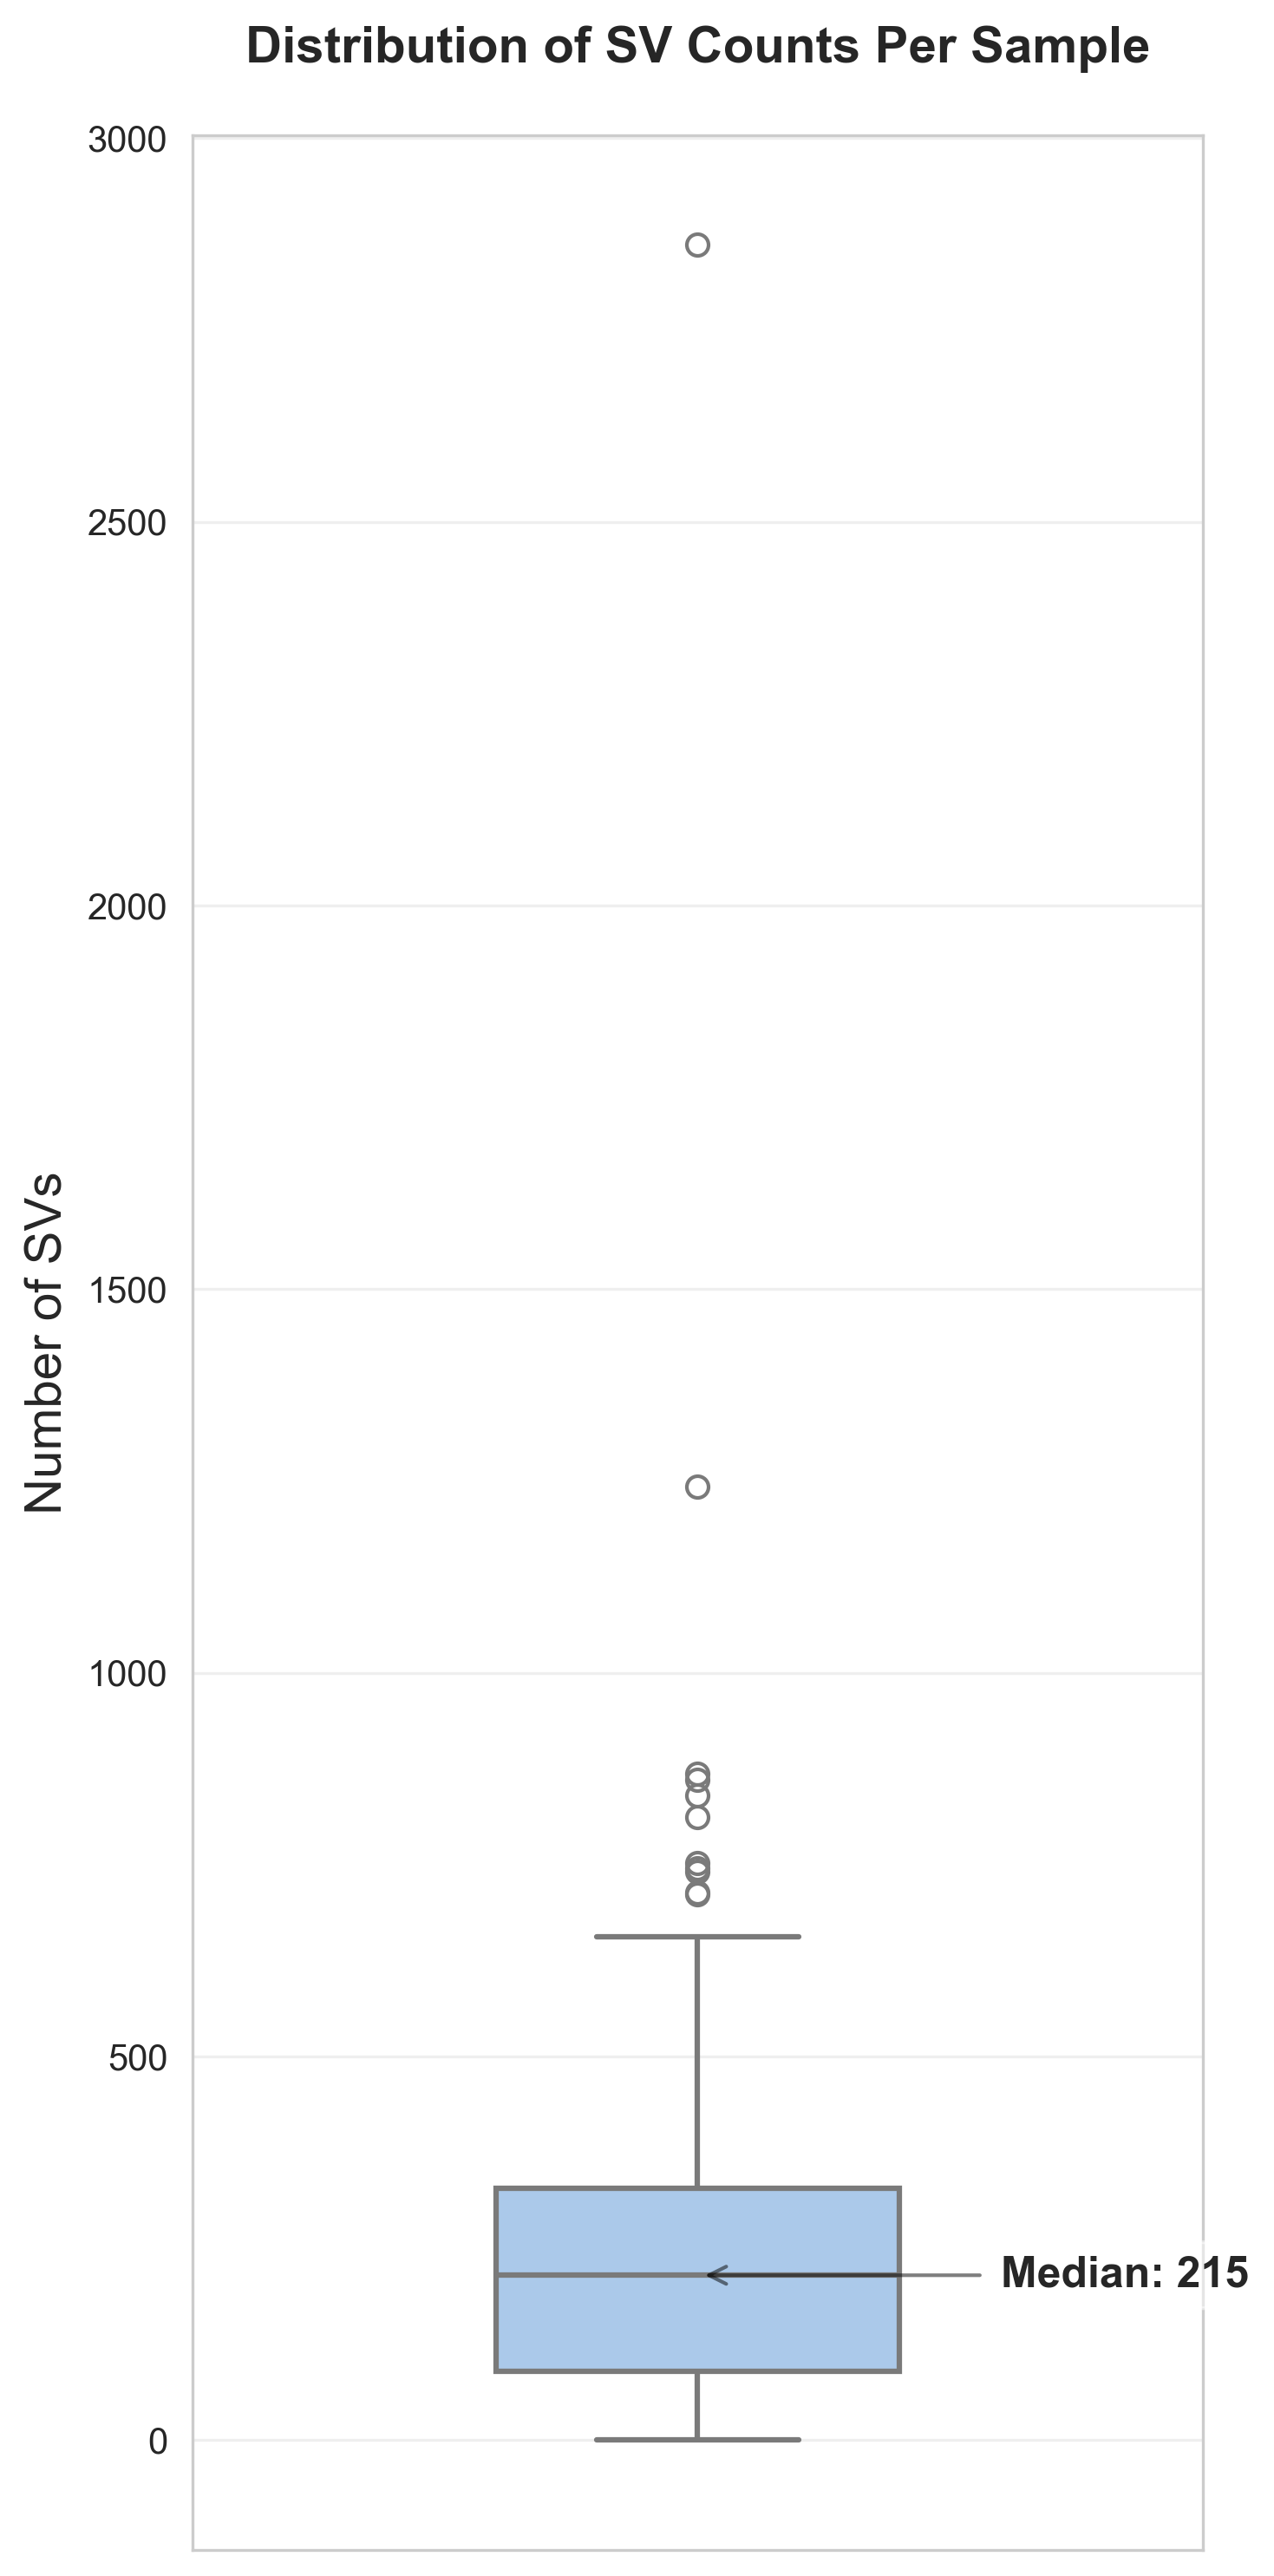

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

sns.set_style("whitegrid")
sns.set_palette("pastel")

# Create the vertical boxplot with filtered data
plt.figure(figsize=(5, 10))
box_plot = sns.boxplot(y=pair_counts['sv_count'], 
                      color=sns.color_palette("pastel")[0],
                      linewidth=1.5,
                      width=0.4)  # Make the box narrower

plt.title('Distribution of SV Counts Per Sample', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of SVs', fontsize=14)
plt.xlabel('')  # Remove x-axis label

# Calculate median for annotation
median_value = pair_counts['sv_count'].median()

# Add median annotation
plt.annotate(f'Median: {median_value:.0f}', 
            xy=(0, median_value), 
            xytext=(0.3, median_value),
            fontsize=12,
            fontweight='bold',
            ha='left',
            va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.5))

plt.tick_params(axis='y', labelsize=10)
plt.grid(True, alpha=0.3, axis='y', linewidth=0.8)
plt.tight_layout()

# Print statistics
print(f"Filtered data statistics (excluding {pair_counts['sv_count'].max():.0f} SV outlier):")
filtered_stats = {
    'Count': len(pair_counts),
    'Min': pair_counts['sv_count'].min(),
    '25th percentile': pair_counts['sv_count'].quantile(0.25),
    '50th percentile (Median)': pair_counts['sv_count'].quantile(0.5),
    '75th percentile': pair_counts['sv_count'].quantile(0.75),
    'Max': pair_counts['sv_count'].max()
}

for stat, value in filtered_stats.items():
    if stat == 'Count':
        print(f"{stat}: {value}")
    else:
        print(f"{stat}: {value:.0f}")

plt.show()

In [17]:
# Calculate average SVs per cohort
cohort_means = pd.merge(included_samples, pair_counts, on='tumor_normal_pair')\
    .groupby('cohort')['sv_count']\
    .agg(['median', 'count'])\
    .round(2)\
    .sort_values('median', ascending=False)

print("Average SVs per cohort:")
print(cohort_means)

Average SVs per cohort:
                    median  count
cohort                           
DFCI_from_CZ_Zhang   316.0      7
dbGaP                279.0     12
StJude               253.0     88
MD_Anderson          157.0      6
DFCI_with_snRNAseq   130.0      8
ICGC                 120.0     51
TARGET               101.0     35


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_71894/3737729332.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ytick_labels)


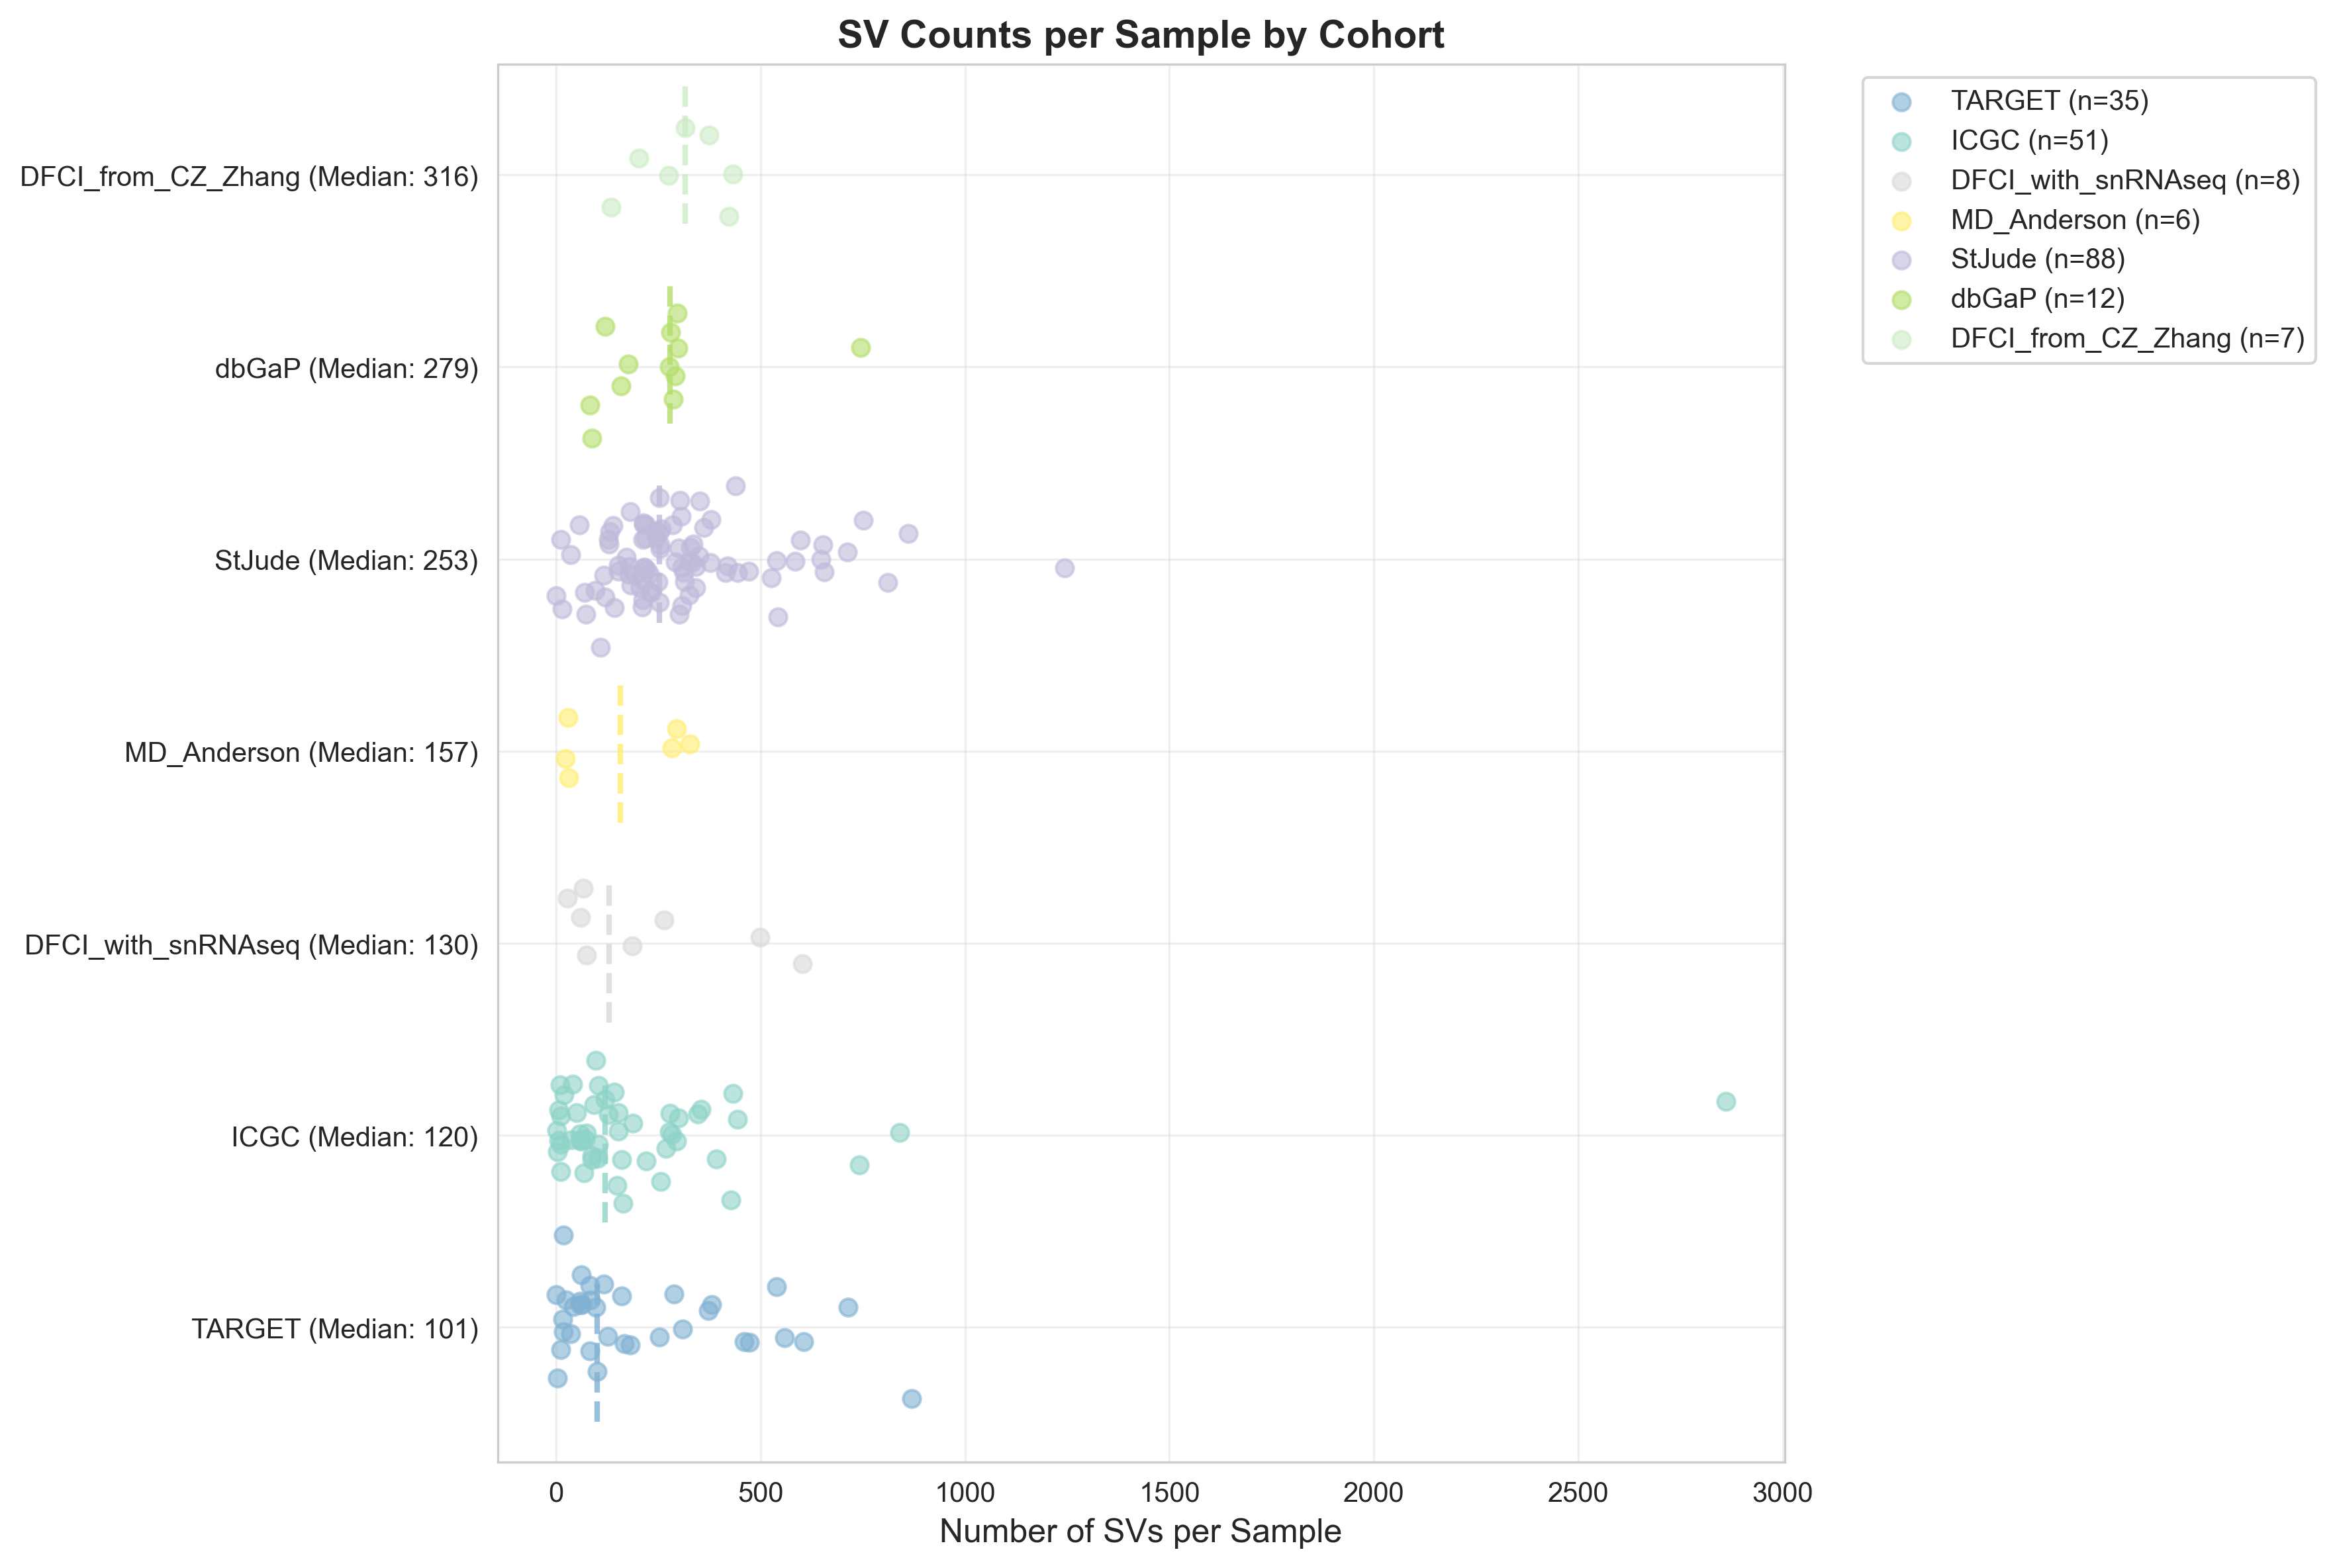

In [21]:
# Merge cohort information with pair_counts
plot_data = pair_counts.merge(
    included_samples[['tumor_normal_pair', 'cohort']], 
    on='tumor_normal_pair', 
    how='left'
)

# Check if any samples are missing cohort information
missing_cohort = plot_data['cohort'].isna().sum()
if missing_cohort > 0:
    print(f"Warning: {missing_cohort} samples are missing cohort information")
    plot_data = plot_data.dropna(subset=['cohort'])

# Calculate medians for each cohort (using filtered data)
cohort_medians = plot_data.groupby('cohort')['sv_count'].median().sort_values()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

cohorts = plot_data['cohort'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(cohorts)))
color_map = dict(zip(cohorts, colors))

for i, cohort in enumerate(cohort_medians.index):
    cohort_data = plot_data[plot_data['cohort'] == cohort]
    y_pos = np.random.normal(i, 0.15, len(cohort_data))
    
    ax.scatter(cohort_data['sv_count'], y_pos, 
               color=color_map[cohort], alpha=0.6, s=40, 
               label=f'{cohort} (n={len(cohort_data)})')
    
    # median line
    median_val = cohort_medians[cohort]
    ax.axvline(x=median_val, ymin=(i+0.2)/len(cohorts), ymax=(i+0.9)/len(cohorts), 
               color=color_map[cohort], linestyle='--', linewidth=2, alpha=0.8)

ax.set_xlabel('Number of SVs per Sample', fontsize=12)
# add median value to cohortlabels
ytick_labels = [f"{cohort} (Median: {int(median)})" for cohort, median in cohort_medians.items()]
ax.set_yticklabels(ytick_labels)
ax.set_yticks(range(len(cohort_medians)))
ax.set_title('SV Counts per Sample by Cohort', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()